## 1.  Подобрать таблицу данных с несбалансированными классами. Решить задачу классификации любым подходящим методом.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_curve, auc, precision_recall_curve,
                             confusion_matrix, classification_report, roc_auc_score, balanced_accuracy_score)
from sklearn.tree import DecisionTreeClassifier
import warnings
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

ModuleNotFoundError: No module named 'kagglehub'

In [ ]:
import os
csv_file = os.path.join(path, 'creditcard.csv')
df = pd.read_csv(csv_file)

df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,-1.593105,2.711941,-0.689256,4.626942,-0.924459,1.107641,1.991691,0.510632,-0.682920,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,-0.150189,0.915802,1.214756,-0.675143,1.164931,-0.711757,-0.025693,-1.221179,-1.545556,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,0.411614,0.063119,-0.183699,-0.510602,1.329284,0.140716,0.313502,0.395652,-0.577252,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,-1.933849,-0.962886,-1.042082,0.449624,1.962563,-0.608577,0.509928,1.113981,2.897849,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [ ]:
df_clean = df.copy()

X = df_clean.drop('Class', axis=1)
y = df_clean['Class']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3,
                                                      random_state=42, stratify=y)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"\nРаспределение классов в обучающей выборке:")
print(y_train.value_counts())
print(f"\nРаспределение классов в тестовой выборке:")
print(y_test.value_counts())
print(f"\nДоля мошенничества в тесте: {(y_test.sum()/len(y_test)*100):.4f}%")

Размер обучающей выборки: (199364, 30)
Размер тестовой выборки: (85443, 30)

Распределение классов в обучающей выборке:
Class
0    199020
1       344
Name: count, dtype: int64

Распределение классов в тестовой выборке:
Class
0    85295
1      148
Name: count, dtype: int64

Доля мошенничества в тесте: 0.1732%


In [ ]:
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print(f"Точность на обучающей выборке: {model.score(X_train, y_train):.4f}")
print(f"Точность на тестовой выборке: {model.score(X_test, y_test):.4f}")

Точность на обучающей выборке: 0.9992
Точность на тестовой выборке: 0.9991


## 2. Вычисление метрик качества: точность, полнота, специфичность

In [ ]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[85279,    16],
       [   59,    89]])

In [ ]:
tn, fp, fn, tp = cm.ravel()


accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
bacc = balanced_accuracy_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
specificity = tn / (tn + fp)

print("\n" + "="*50)
print("МЕТРИКИ КАЧЕСТВА КЛАССИФИКАЦИИ")
print("="*50)
print(f"Accuracy (Точность):      {accuracy:.4f}")
print(f"Precision (Точность):     {precision:.4f}")
print(f"Recall (Полнота):         {recall:.4f}")
print(f"Specificity (Специфичность): {specificity:.4f}")
print("="*50)


МЕТРИКИ КАЧЕСТВА КЛАССИФИКАЦИИ
Accuracy (Точность):      0.9991
Precision (Точность):     0.8476
Recall (Полнота):         0.6014
Specificity (Специфичность): 0.9998


In [ ]:

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Норма (0)', 'Мошенничество (1)'],
            yticklabels=['Норма (0)', 'Мошенничество (1)'])
plt.title('Матрица ошибок', fontsize=16, fontweight='bold')
plt.ylabel('Истинные значения', fontsize=12)
plt.xlabel('Предсказанные значения', fontsize=12)
plt.tight_layout()
plt.show()


NameError: name 'cm' is not defined

<Figure size 800x600 with 0 Axes>

## 3. Построить кривую ошибок и найти площадь под ней. Построить кривую "точность-полнота".


AUC (Area Under Curve): 0.9575
Balanced Accuracy: 0.8006
ROCAUC: 0.9575


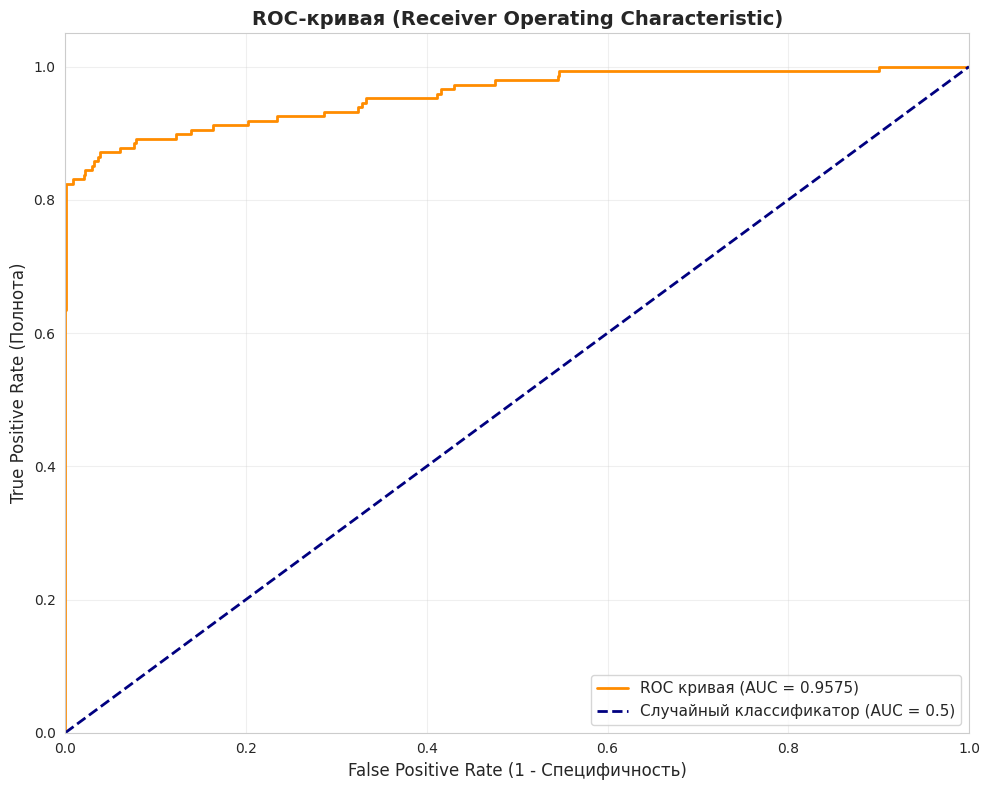

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)


print(f"AUC (Area Under Curve): {roc_auc:.4f}")
print(f"Balanced Accuracy: {bacc:.4f}")
print(f"ROCAUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC кривая (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
         label='Случайный классификатор (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Специфичность)', fontsize=12)
plt.ylabel('True Positive Rate (Полнота)', fontsize=12)
plt.title('ROC-кривая (Receiver Operating Characteristic)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

PR-AUC (Precision-Recall AUC): 0.7058


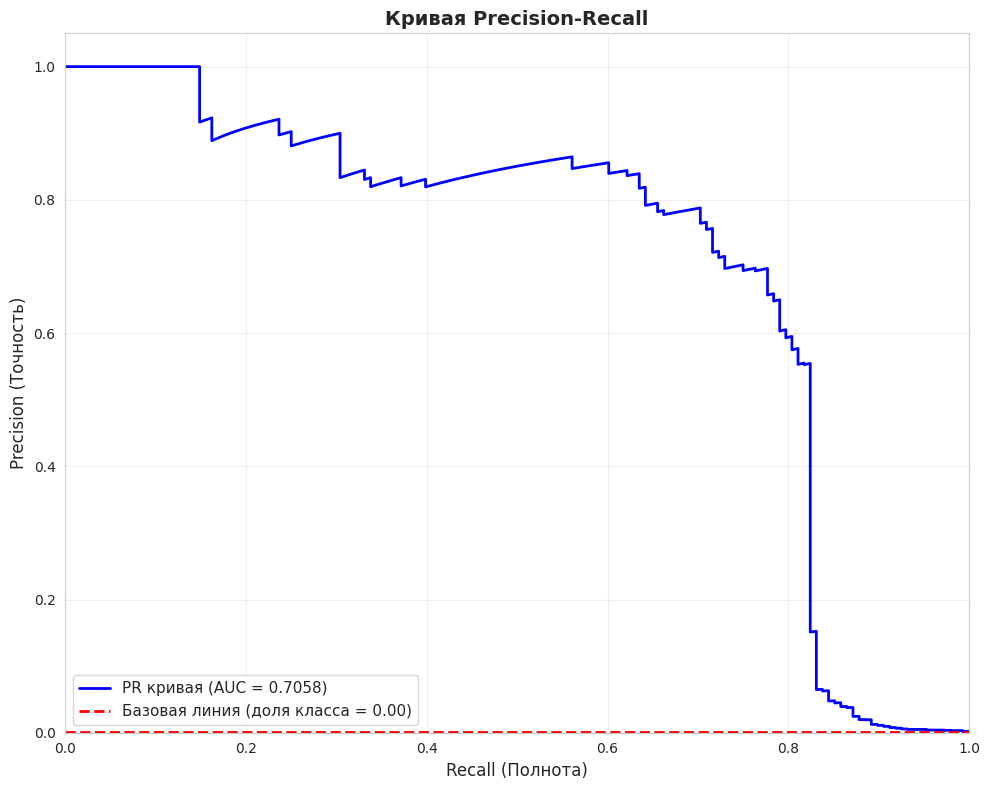

In [ ]:
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall_vals, precision_vals)

print(f"PR-AUC (Precision-Recall AUC): {pr_auc:.4f}")

plt.figure(figsize=(10, 8))
plt.plot(recall_vals, precision_vals, color='blue', lw=2,
         label=f'PR кривая (AUC = {pr_auc:.4f})')

baseline = sum(y_test) / len(y_test)
plt.plot([0, 1], [baseline, baseline], 'r--', lw=2,
         label=f'Базовая линия (доля класса = {baseline:.2f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall (Полнота)', fontsize=12)
plt.ylabel('Precision (Точность)', fontsize=12)
plt.title('Кривая Precision-Recall', fontsize=14, fontweight='bold')
plt.legend(loc="lower left", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Разбить данные на обучающую и контрольную выборки. Построить ROC- кривую для каждой из подвыборок. Построить ROC- кривую на основе кроссвалидации (объединить прогнозы для разных фолдов).

AUC на обучающей выборке: 0.9853
AUC на тестовой выборке:  0.9575
Разница: 0.0278


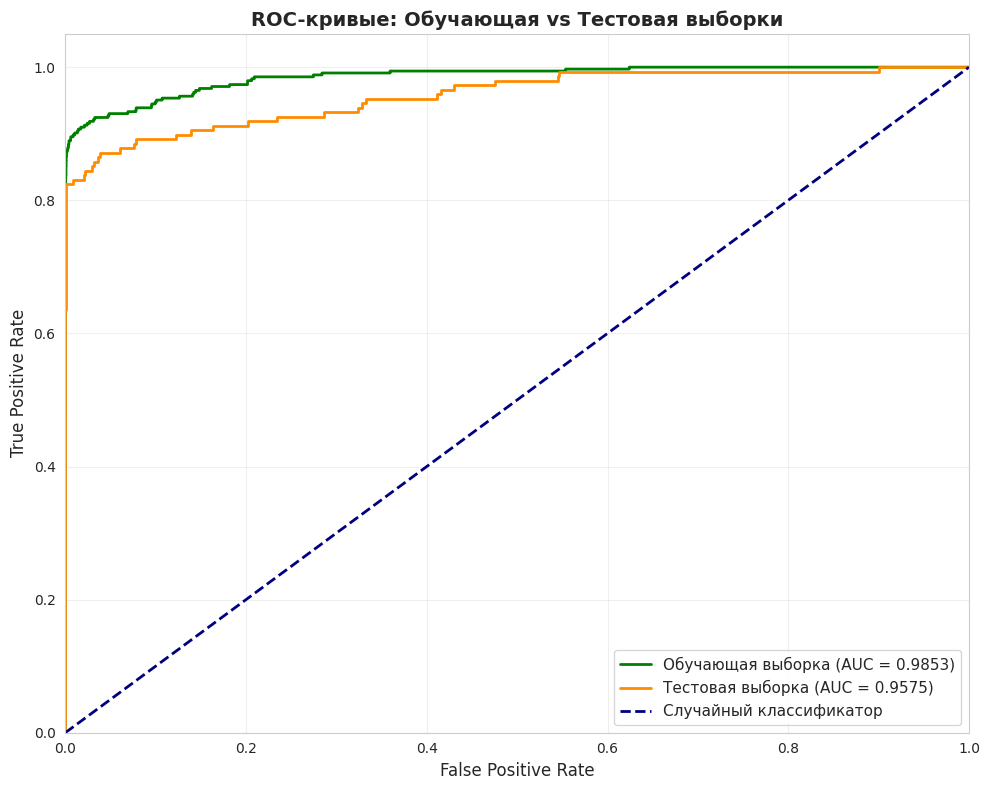

In [ ]:
y_train_pred_proba = model.predict_proba(X_train)[:, 1]

fpr_train, tpr_train, _ = roc_curve(y_train, y_train_pred_proba)
roc_auc_train = auc(fpr_train, tpr_train)

roc_auc_test = roc_auc

print(f"AUC на обучающей выборке: {roc_auc_train:.4f}")
print(f"AUC на тестовой выборке:  {roc_auc_test:.4f}")
print(f"Разница: {abs(roc_auc_train - roc_auc_test):.4f}")

plt.figure(figsize=(10, 8))
plt.plot(fpr_train, tpr_train, color='green', lw=2,
         label=f'Обучающая выборка (AUC = {roc_auc_train:.4f})')
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'Тестовая выборка (AUC = {roc_auc_test:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
         label='Случайный классификатор')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC-кривые: Обучающая vs Тестовая выборки', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_pred_proba_cv = cross_val_predict(model, X_scaled, y, cv=cv, method='predict_proba')[:, 1]

fpr_cv, tpr_cv, _ = roc_curve(y, y_pred_proba_cv)
roc_auc_cv = auc(fpr_cv, tpr_cv)

print(f"AUC на кросс-валидации (5 фолдов): {roc_auc_cv:.4f}")

plt.figure(figsize=(10, 8))
plt.plot(fpr_cv, tpr_cv, color='purple', lw=2,
         label=f'Кросс-валидация (AUC = {roc_auc_cv:.4f})')
plt.plot(fpr, tpr, color='darkorange', lw=2, alpha=0.7,
         label=f'Одно разбиение (AUC = {roc_auc_test:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
         label='Случайный классификатор')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC-кривая: Кросс-валидация vs Одно разбиение', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Исследовать влияние выбора критерия обучения на AUC. Один из критериев — log loss, ещё один или два — на выбор. Как вариант: сравнить AdaBoost с градиентным бустингом.

In [ ]:
# 1. Логистическая регрессия (Log Loss)
lr_auc = roc_auc_score(y_test, y_pred_proba)
lr_auc

In [ ]:
# 2. AdaBoost
ada_model = AdaBoostClassifier(n_estimators=100, random_state=42,
                                algorithm='SAMME')
ada_model.fit(X_train, y_train)
ada_proba = ada_model.predict_proba(X_test)[:, 1]
ada_auc = roc_auc_score(y_test, ada_proba)

In [ ]:
# 3. Gradient Boosting (использует deviance/log loss)
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42,
                                       learning_rate=0.1, max_depth=3)
gb_model.fit(X_train, y_train)
gb_proba = gb_model.predict_proba(X_test)[:, 1]
gb_auc = roc_auc_score(y_test, gb_proba)


In [ ]:

# Результаты
print("="*70)
print("СРАВНЕНИЕ МОДЕЛЕЙ И КРИТЕРИЕВ ОБУЧЕНИЯ")
print("="*70)
print(f"1. Logistic Regression (Log Loss):        AUC = {lr_auc:.4f}")
print(f"2. AdaBoost (Exponential Loss):           AUC = {ada_auc:.4f}")
print(f"3. Gradient Boosting (Deviance/Log Loss): AUC = {gb_auc:.4f}")
print("="*70)

In [ ]:
plt.figure(figsize=(12, 8))

models_data = [
    (y_pred_proba, 'Logistic Regression (Log Loss)', 'blue'),
    (ada_proba, 'AdaBoost (Exp. Loss)', 'red'),
    (gb_proba, 'Gradient Boosting (Log Loss)', 'purple')
]

for proba, name, color in models_data:
    fpr_temp, tpr_temp, _ = roc_curve(y_test, proba)
    auc_temp = auc(fpr_temp, tpr_temp)
    plt.plot(fpr_temp, tpr_temp, lw=2, color=color,
             label=f'{name} (AUC = {auc_temp:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Случайный классификатор')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Сравнение ROC-кривых различных моделей', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
models_names = ['LogReg\n(Log Loss)', 'AdaBoost\n(Exp. Loss)', 'GradBoost\n(Log Loss)']
auc_scores = [lr_auc, ada_auc, gb_auc]
colors_bar = ['blue', 'red', 'purple']

plt.figure(figsize=(12, 6))
bars = plt.bar(models_names, auc_scores, color=colors_bar, alpha=0.7, edgecolor='black')

for i, (bar, score) in enumerate(zip(bars, auc_scores)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='Случайный классификатор')
plt.ylim([0, 1.1])
plt.ylabel('AUC Score', fontsize=12)
plt.xlabel('Модель и критерий обучения', fontsize=12)
plt.title('Сравнение AUC для различных моделей и критериев', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

best_idx = np.argmax(auc_scores)
print(f"\nЛучшая модель: {models_names[best_idx].replace(chr(10), ' ')} с AUC = {auc_scores[best_idx]:.4f}")